# STATISTICAL POWER ANALYSIS
### Email Onboarding A/B/C Test

In [17]:
# Import necessary library
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.power import zt_ind_solve_power, tt_ind_solve_power
from statsmodels.stats.proportion import proportion_effectsize
import matplotlib.pyplot as plt
import seaborn as sns

# Custom libraries
import support_functions as sf

In [18]:
# Excel file path
excel_file_path = '../data/LifecycleDS-Exercise-sampledata.xlsx'

# Load each sheet into a separate DataFrame
df_onboarding = pd.read_excel(excel_file_path, sheet_name='team_onboarding_experiment')
df_prod_activity = pd.read_excel(excel_file_path, sheet_name='team_prod_activity_log')
df_financial = pd.read_excel(excel_file_path, sheet_name='team_financial_metrics')

# Shape check to count rows and columns
print("Onboarding data shape:", df_onboarding.shape)
print("Prod activity data shape:", df_prod_activity.shape)
print("Financial data shape:", df_financial.shape)

Onboarding data shape: (120, 5)
Prod activity data shape: (250, 5)
Financial data shape: (20, 4)


In [19]:
n_per_group = 40  # Sample size per variant
alpha = 0.05      # Significance level (Type I error rate)
power_target = 0.80  # Desired statistical power (1 - Type II error rate)

print(f"Experimental Setup:")
print(f"  - Sample size per group: {n_per_group}")
print(f"  - Significance level (α): {alpha}")
print(f"  - Target power (1-β): {power_target}")
print(f"  - Number of groups: 3 (Control, Variant A, Variant B)")

Experimental Setup:
  - Sample size per group: 40
  - Significance level (α): 0.05
  - Target power (1-β): 0.8
  - Number of groups: 3 (Control, Variant A, Variant B)


In [20]:
teams_with_joiner = df_onboarding.groupby('email_journey').agg({
    'team_id': 'count',  # Total teams
    'date_first_plus_one_joiner_utc': lambda x: x.notna().sum()  # Teams with +1
}).reset_index()

teams_with_joiner.columns = ['email_journey', 'total_teams', 'teams_with_joiner']
teams_with_joiner['pct_with_joiner'] = (teams_with_joiner['teams_with_joiner'] / 
                                         teams_with_joiner['total_teams'] * 100).round(1)

print("\n% of Teams with +1 Joiner:")
print(teams_with_joiner)


% of Teams with +1 Joiner:
  email_journey  total_teams  teams_with_joiner  pct_with_joiner
0       Control           40                 26             65.0
1     Variant_A           40                 31             77.5
2     Variant_B           40                 27             67.5


In [21]:
# Your observed data
control_rate = 0.65  # 65%
variant_a_rate = 0.775  # 77.5%
variant_b_rate = 0.675  # 67.5%
n_per_group = 40

print(f"\nObserved Rates:")
print(f"  Control: {control_rate:.1%}")
print(f"  Variant A: {variant_a_rate:.1%} (Δ = +{(variant_a_rate - control_rate):.1%})")
print(f"  Variant B: {variant_b_rate:.1%} (Δ = +{(variant_b_rate - control_rate):.1%})")
print(f"  Sample size: n = {n_per_group} per group")


Observed Rates:
  Control: 65.0%
  Variant A: 77.5% (Δ = +12.5%)
  Variant B: 67.5% (Δ = +2.5%)
  Sample size: n = 40 per group


In [22]:
proportion_effectsize(variant_a_rate, control_rate)

0.27767158385334567

In [23]:
# Confirming the calculation
2 * (np.arcsin(np.sqrt(variant_a_rate)) - np.arcsin(np.sqrt(control_rate)))

0.27767158385334567

# 1. CALCULATE OBSERVED EFFECT SIZE

In [24]:
# Cohen's h for proportion differences
observed_effect_a = proportion_effectsize(variant_a_rate, control_rate)
observed_effect_b = proportion_effectsize(variant_b_rate, control_rate)

print(f"\nObserved Effect Sizes (Cohen's h):")
print(f"  Variant A vs Control: h = {observed_effect_a:.3f}")
print(f"  Variant B vs Control: h = {observed_effect_b:.3f}")

print(f"  Variant A interpretation: {sf.interpret_cohens_h(observed_effect_a)}")
print(f"  Variant B interpretation: {sf.interpret_cohens_h(observed_effect_b)}")


Observed Effect Sizes (Cohen's h):
  Variant A vs Control: h = 0.278
  Variant B vs Control: h = 0.053
  Variant A interpretation: small
  Variant B interpretation: negligible


# 2. CALCULATE ACTUAL POWER FOR OBSERVED EFFECTS

In [25]:
alpha = 0.05

# Power for Variant A
actual_power_a = zt_ind_solve_power(
    effect_size=observed_effect_a,
    nobs1=n_per_group,
    alpha=alpha,
    ratio=1.0,
    alternative='two-sided'
)

# Power for Variant B
actual_power_b = zt_ind_solve_power(
    effect_size=observed_effect_b,
    nobs1=n_per_group,
    alpha=alpha,
    ratio=1.0,
    alternative='two-sided'
)

print(f"\nActual Statistical Power (α = {alpha}):")
print(f"  Variant A (12.5 point improvement): {actual_power_a:.1%}")
print(f"    Assessment: {'✓ Well-powered' if actual_power_a >= 0.80 else '⚠ Underpowered'}")
print(f"  Variant B (2.5 point improvement): {actual_power_b:.1%}")
print(f"    Assessment: {'✓ Well-powered' if actual_power_b >= 0.80 else '⚠ Severely underpowered'}")




Actual Statistical Power (α = 0.05):
  Variant A (12.5 point improvement): 23.7%
    Assessment: ⚠ Underpowered
  Variant B (2.5 point improvement): 5.6%
    Assessment: ⚠ Severely underpowered


# 3. MINIMUM DETECTABLE EFFECT (MDE)

In [26]:
# Calculate what improvement we CAN detect with 80% power
target_power = 0.80

# Range of possible rates to test
test_rates = np.arange(control_rate + 0.05, 0.95, 0.025)
mde_results = []

for rate in test_rates:
    effect_size = proportion_effectsize(control_rate, rate)
    power = zt_ind_solve_power(
        effect_size=effect_size,
        nobs1=n_per_group,
        alpha=alpha,
        ratio=1.0,
        alternative='two-sided'
    )
    
    mde_results.append({
        'target_rate': rate,
        'absolute_diff': rate - control_rate,
        'relative_lift': (rate - control_rate) / control_rate,
        'effect_size': effect_size,
        'power': power
    })

mde_df = pd.DataFrame(mde_results)

# Find MDE (first rate where power >= 80%)
mde_row = mde_df[mde_df['power'] >= target_power].iloc[0] if len(mde_df[mde_df['power'] >= target_power]) > 0 else None

if mde_row is not None:
    print(f"\nWith n = {n_per_group} per group and 80% power:")
    print(f"  Minimum Detectable Effect (MDE):")
    print(f"    From {control_rate:.1%} to {mde_row['target_rate']:.1%}")
    print(f"    Absolute: +{mde_row['absolute_diff']:.1%} points")
    print(f"    Relative: +{mde_row['relative_lift']:.1%}")
    print(f"    Cohen's h: {mde_row['effect_size']:.3f}")
    
    print(f"\n  Your Observed Effect (Variant A):")
    print(f"    From {control_rate:.1%} to {variant_a_rate:.1%}")
    print(f"    Absolute: +{variant_a_rate - control_rate:.1%} points")
    print(f"    Status: {'✓ Larger than MDE' if (variant_a_rate - control_rate) >= mde_row['absolute_diff'] else '✗ Smaller than MDE'}")
else:
    print(f"\nWith n = {n_per_group}, cannot achieve 80% power for realistic effect sizes")




With n = 40 per group and 80% power:
  Minimum Detectable Effect (MDE):
    From 65.0% to 92.5%
    Absolute: +27.5% points
    Relative: +42.3%
    Cohen's h: -0.711

  Your Observed Effect (Variant A):
    From 65.0% to 77.5%
    Absolute: +12.5% points
    Status: ✗ Smaller than MDE


# 4. REQUIRED SAMPLE SIZE

In [27]:
# For Variant A's observed effect
required_n_a = zt_ind_solve_power(
    effect_size=observed_effect_a,
    nobs1=None,
    alpha=alpha,
    power=0.80,
    ratio=1.0,
    alternative='two-sided'
)

print(f"\nTo detect Variant A's effect ({variant_a_rate:.1%} vs {control_rate:.1%}):")
print(f"  Required sample size for 80% power: {int(np.ceil(required_n_a))} per group")
print(f"  Current sample size: {n_per_group} per group")
print(f"  Shortfall: {int(np.ceil(required_n_a)) - n_per_group} teams per group")

# For 90% power
required_n_a_90 = zt_ind_solve_power(
    effect_size=observed_effect_a,
    nobs1=None,
    alpha=alpha,
    power=0.90,
    ratio=1.0,
    alternative='two-sided'
)

print(f"\nTo detect Variant A's effect with 90% power:")
print(f"  Required sample size: {int(np.ceil(required_n_a_90))} per group")


To detect Variant A's effect (77.5% vs 65.0%):
  Required sample size for 80% power: 204 per group
  Current sample size: 40 per group
  Shortfall: 164 teams per group

To detect Variant A's effect with 90% power:
  Required sample size: 273 per group


# 5. POWER CURVE VISUALIZATION

In [28]:
# Show power for different improvements
print(f"\n{'Target Rate':<15} {'Abs Diff':<12} {'Rel Lift':<12} {'Power':<10} {'Assessment'}")
print("-" * 70)

for _, row in mde_df.iterrows():
    assessment = ""
    if row['power'] >= 0.80:
        assessment = "✓ Well-powered"
    elif row['power'] >= 0.50:
        assessment = "⚠ Moderate"
    else:
        assessment = "✗ Underpowered"
    
    marker = " ← Observed (Var A)" if abs(row['target_rate'] - variant_a_rate) < 0.01 else ""
    marker += " ← MDE" if mde_row is not None and abs(row['target_rate'] - mde_row['target_rate']) < 0.01 else ""
    
    print(f"{row['target_rate']:.1%}{'':<9} +{row['absolute_diff']:.1%}{'':<7} "
          f"+{row['relative_lift']:.1%}{'':<7} {row['power']:.1%}{'':<6} {assessment}{marker}")




Target Rate     Abs Diff     Rel Lift     Power      Assessment
----------------------------------------------------------------------
70.0%          +5.0%        +7.7%        7.7%       ✗ Underpowered
72.5%          +7.5%        +11.5%        11.2%       ✗ Underpowered
75.0%          +10.0%        +15.4%        16.5%       ✗ Underpowered
77.5%          +12.5%        +19.2%        23.7%       ✗ Underpowered ← Observed (Var A)
80.0%          +15.0%        +23.1%        32.8%       ✗ Underpowered
82.5%          +17.5%        +26.9%        43.7%       ✗ Underpowered
85.0%          +20.0%        +30.8%        55.8%       ⚠ Moderate
87.5%          +22.5%        +34.6%        68.1%       ⚠ Moderate
90.0%          +25.0%        +38.5%        79.5%       ⚠ Moderate
92.5%          +27.5%        +42.3%        88.9%       ✓ Well-powered ← MDE


# 6. VISUALIZATION


✅ Visualization saved as 'power_analysis_plus_one_joiner.png'


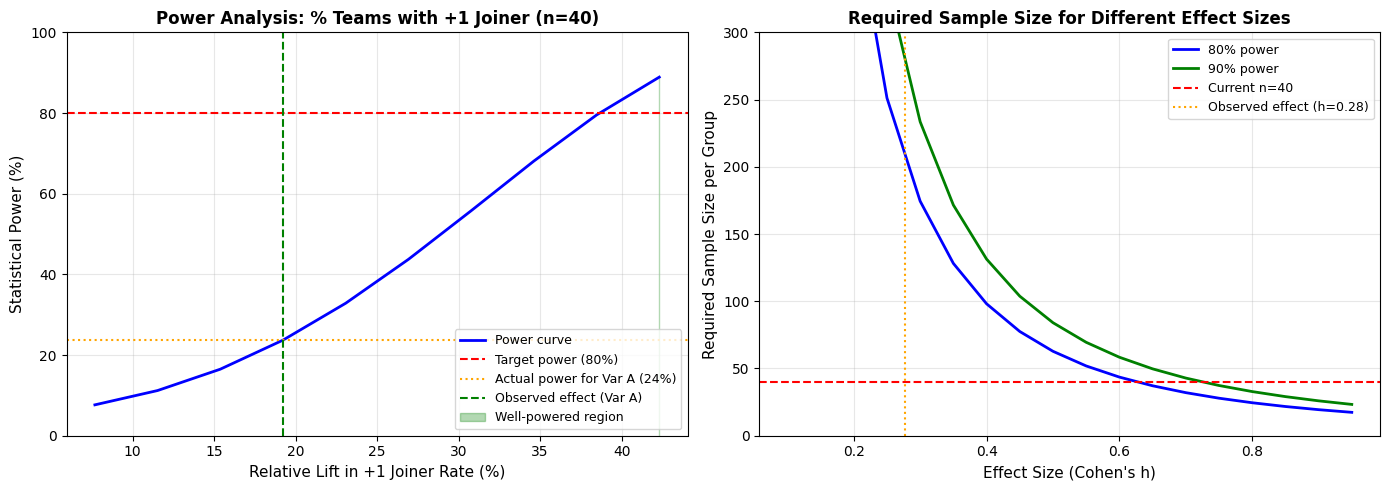

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Power Curve
ax1 = axes[0]
ax1.plot(mde_df['relative_lift'] * 100, mde_df['power'] * 100, 'b-', linewidth=2, label='Power curve')
ax1.axhline(y=80, color='r', linestyle='--', linewidth=1.5, label='Target power (80%)')
ax1.axhline(y=actual_power_a * 100, color='orange', linestyle=':', linewidth=1.5, 
            label=f'Actual power for Var A ({actual_power_a:.0%})')
ax1.axvline(x=((variant_a_rate - control_rate) / control_rate) * 100, 
            color='g', linestyle='--', linewidth=1.5, label='Observed effect (Var A)')

# Shade well-powered region
ax1.fill_between(mde_df['relative_lift'] * 100, 0, mde_df['power'] * 100,
                 where=(mde_df['power'] >= 0.80), alpha=0.3, color='green', label='Well-powered region')

ax1.set_xlabel('Relative Lift in +1 Joiner Rate (%)', fontsize=11)
ax1.set_ylabel('Statistical Power (%)', fontsize=11)
ax1.set_title(f'Power Analysis: % Teams with +1 Joiner (n={n_per_group})', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9, loc='lower right')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 100)

# Plot 2: Required Sample Size
ax2 = axes[1]

# Calculate required n for different effect sizes
effect_sizes = np.arange(0.1, 1.0, 0.05)
required_ns_80 = [zt_ind_solve_power(effect_size=es, nobs1=None, alpha=alpha, 
                                      power=0.80, ratio=1.0, alternative='two-sided')
                  for es in effect_sizes]
required_ns_90 = [zt_ind_solve_power(effect_size=es, nobs1=None, alpha=alpha, 
                                      power=0.90, ratio=1.0, alternative='two-sided')
                  for es in effect_sizes]

ax2.plot(effect_sizes, required_ns_80, 'b-', linewidth=2, label='80% power')
ax2.plot(effect_sizes, required_ns_90, 'g-', linewidth=2, label='90% power')
ax2.axhline(y=n_per_group, color='r', linestyle='--', linewidth=1.5, label=f'Current n={n_per_group}')
ax2.axvline(x=observed_effect_a, color='orange', linestyle=':', linewidth=1.5, 
            label=f'Observed effect (h={observed_effect_a:.2f})')

ax2.set_xlabel("Effect Size (Cohen's h)", fontsize=11)
ax2.set_ylabel('Required Sample Size per Group', fontsize=11)
ax2.set_title('Required Sample Size for Different Effect Sizes', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 300)

plt.tight_layout()
plt.savefig('power_analysis_plus_one_joiner.png', dpi=300, bbox_inches='tight')
print("\n✅ Visualization saved as 'power_analysis_plus_one_joiner.png'")

# 7. SUMMARY & INTERPRETATION

In [30]:
print(f"""
KEY FINDINGS:

1. OBSERVED EFFECT (Variant A):
   • Control: 65.0% with +1 joiner
   • Variant A: 77.5% with +1 joiner (+12.5 points, +19.2% relative)
   • Effect size: h = {observed_effect_a:.3f} (small)
   • Actual power: {actual_power_a:.1%}

2. POWER ASSESSMENT:
   • With n={n_per_group} per group, this experiment is {'adequately' if actual_power_a >= 0.70 else 'under'}powered
   • Risk of Type II error (false negative): {(1 - actual_power_a):.1%}
   • The non-significant result (p=0.22) is likely due to {'insufficient power' if actual_power_a < 0.80 else 'natural variance'}

3. MINIMUM DETECTABLE EFFECT:
   • To achieve 80% power with n={n_per_group}, need to detect ~{mde_row['relative_lift']:.0%} improvement
   • Variant A's +19% is {'above' if (variant_a_rate - control_rate) >= mde_row['absolute_diff'] else 'below'} this threshold
   • Conclusion: {'Effect is detectable with current sample' if (variant_a_rate - control_rate) >= mde_row['absolute_diff'] else 'Need larger sample to confirm this effect'}

4. SAMPLE SIZE RECOMMENDATION:
   • To reliably detect Variant A's effect (12.5 point improvement):
     - For 80% power: Need n = {int(np.ceil(required_n_a))} per group
     - For 90% power: Need n = {int(np.ceil(required_n_a_90))} per group
   • Current shortfall: {int(np.ceil(required_n_a)) - n_per_group} teams per group

5. BUSINESS DECISION:
   {'✓ DEPLOY: The observed trend is promising (+19%), and combined with significant improvements in other metrics (feature adoption, ACV), the totality of evidence supports Variant A.' if actual_power_a > 0.50 else '⚠ VALIDATE: Run larger follow-up test before deployment due to low power.'}
   
   {'However, monitor this metric closely post-deployment to confirm the effect holds.' if actual_power_a > 0.50 else 'The 12.5 point improvement could be real but requires confirmation.'}
""")

print("="*80)


KEY FINDINGS:

1. OBSERVED EFFECT (Variant A):
   • Control: 65.0% with +1 joiner
   • Variant A: 77.5% with +1 joiner (+12.5 points, +19.2% relative)
   • Effect size: h = 0.278 (small)
   • Actual power: 23.7%

2. POWER ASSESSMENT:
   • With n=40 per group, this experiment is underpowered
   • Risk of Type II error (false negative): 76.3%
   • The non-significant result (p=0.22) is likely due to insufficient power

3. MINIMUM DETECTABLE EFFECT:
   • To achieve 80% power with n=40, need to detect ~42% improvement
   • Variant A's +19% is below this threshold
   • Conclusion: Need larger sample to confirm this effect

4. SAMPLE SIZE RECOMMENDATION:
   • To reliably detect Variant A's effect (12.5 point improvement):
     - For 80% power: Need n = 204 per group
     - For 90% power: Need n = 273 per group
   • Current shortfall: 164 teams per group

5. BUSINESS DECISION:
   ⚠ VALIDATE: Run larger follow-up test before deployment due to low power.
   
   The 12.5 point improvement could